### Kursbezeichnung:

Projekt: Programmierung mit Python (DLBFTPPP01)

### Aufgabenstellung 2:

Vergleich von Aktien

### Studiengang:

Softwareentwicklung

### Datum:

xx.xx.2026

### Verfasser:

Dustin Vetter, Matrikelnummer IU14110854

# Wer gewinnt das KI-Wettrüsten?

## Ein Aktienvergleich entlang der KI-Wertschöpfungskette

### Gliederung

1. Einleitung
2. Projektvorgehen
3. Kennzahlen zu Rendite und Risiko
4. Gesamtbild und Vergleich
5. Fazit und Reflexion

# 1. Einleitung

## Aktualität und Relevanz des Themas

- Veröffentlichung von ChatGPT Ende 2022 als öffentlich wahrgenommener Auslöser des aktuellen KI-Booms
- Seitdem deutlich steigende Investitionen großer Technologiekonzerne in KI-Infrastruktur
- Generative KI-Anwendungen haben sich zu einem strategischen Schwerpunkt der gesamten Technologiebranche entwickelt

## Untersuchungsgegenstand

- Der öffentlichen Diskurs dreht sich hauptsächlich um generative KI, z. B. ChatGPT, Claude und Mistral AI
- Diese Unternehmen sind privat finanziert und (noch) nicht börsennotiert, es liegen keine Kursdaten vor
- Deshalb werden zentrale Investitionspartner betrachtet mit unmittelbaren Bezug zur KI-Wertschöpfungskette

### Untersuchte Hardware-Unternehmen

- ASML (Niederlande): Lithografieanlagen für die Chipfertigung
- TSMC (Taiwan): größter Auftragsfertiger von Halbleitern
- NVIDIA (USA): marktführende KI-Grafikprozessoren

### Untersuchte Software-Unternehmen

- Microsoft (USA): Cloud-Plattform Azure, Investor bei OpenAI (ChatGPT)
- Amazon (USA): Cloud-Plattform AWS, Investor bei Anthropic (Claude)

## Zielsetzung und Leitfrage

### Leitfrage

Bewegen sich die Aktienkurse von Unternehmen derselben Ebene (Hardware bzw. Software) stärker im Gleichlauf als die Kurse von Unternehmen unterschiedlicher Ebenen?

### Annahme

* Aktien innerhalb derselben Ebene verhalten sich tendenziell ähnlicher als über die Ebenen hinweg
* Hardware-Ebene: stärkerer Gleichlauf zu erwarten, da sch die Unternehmen in der Lieferkette ergänzen statt konkurrieren
* Software-Ebene: schwächerer Gleichlauf zu erwarten, da die Unternehmen im direkten Wettbewerb um Marktanteile stehen

### Überprüfung

Die Annahme wird im weiteren Verlauf anhand einer Korrelationsanalyse der Aktienrendite überprüft. Das methodische Vorgehen dazu folgt im nächsten Kapitel.

# 2. Projektvorgehen

## Import der benötigten Bibliotheken

In [1]:
import yfinance
import pandas
import plotly.express

- yfinance für den Datenabruf
- pandas für die Datenverarbeitung
- plotly für die interaktive Visualisierung

## Abruf der Kursdaten

In [2]:
hardware_unternehmen = ["NVDA", "TSM", "ASML"]
software_unternehmen = ["MSFT", "AMZN"]
alle_unternehmen = hardware_unternehmen + software_unternehmen

alle_daten = yfinance.download(alle_unternehmen, start="2021-08-01", end="2026-07-31", auto_adjust=True)

[*********************100%***********************]  5 of 5 completed


* **start**: Startdatum, 01.08.2021
* **end**: Enddatum, 31.07.2026
* **auto_adjust**: Bereinigt Kurse um Aktiensplits und Dividenden

### Begriffserklärung

- **Aktiensplit**: Aufteilung einer Aktie in mehrere neue Aktien bei gleichbleibendem Gesamtwert des Investments (TODO: Quelle)
    - Beispiel: 1 Aktie zu 1000 USD wird zu 10 Aktien zu je 100 USD
    - Ohne Bereinigung würde ein Split in den historischen Daten wie ein Kurssturz aussehen
* **Dividende**: Ausschüttung eines Teils des Unternehmensgewinns an die Aktionäre (TODO: Quelle)
    - Der Kurs sinkt am Auszahlungstag rechnerisch um den ausgeschütteten Betrag, ohne dass ein realer Wertverlust vorliegt

## Prüfen, ob die Daten korrekt geladen wurden

In [3]:
alle_daten.head()

Price            Close                                                 \
Ticker            AMZN        ASML        MSFT       NVDA         TSM   
Date                                                                    
2021-08-02  166.574005  734.308716  272.827209  19.681921  107.721474   
2021-08-03  168.311996  743.734924  275.030396  19.746702  109.150253   
2021-08-04  167.735992  758.952454  274.446136  20.204115  109.454437   
2021-08-05  168.799500  758.256104  277.329285  20.565863  109.896904   
2021-08-06  167.246994  747.312805  277.271820  20.295799  108.965889   

Price             High                                                 ...  \
Ticker            AMZN        ASML        MSFT       NVDA         TSM  ...   
Date                                                                   ...   
2021-08-02  167.945999  740.214482  274.695084  19.892194  109.122606  ...   
2021-08-03  169.550003  744.612663  275.135779  20.152299  109.362263  ...   
2021-08-04  169.444000  761.900590  275.480649  20.247964  110.201099  ...   
2021-08-05  169.449997  768.646063  277.434668  20.661532  109.915337  ...   
2021-08-06  168.750000  751.043237  277.310144  20.499097  109.325390  ...   

Price             Open                                                 \
Ticker            AMZN        ASML        MSFT       NVDA         TSM   
Date                                                                    
2021-08-02  167.654999  735.415425  274.302344  19.632094  108.311425   
2021-08-03  167.035995  735.148194  273.401994  19.671960  108.136268   
2021-08-04  168.967499  755.641820  274.168339  19.921093  109.168682   
2021-08-05  167.811005  768.522027  274.800461  20.429336  109.758633   
2021-08-06  168.750000  748.476756  276.361839  20.453256  109.113380   

Price         Volume                                        
Ticker          AMZN    ASML      MSFT       NVDA      TSM  
Date                                                        
2021-08-02  67078000  499900  16267400  217444000  6028800  
2021-08-03  83146000  533700  17879000  301811000  5874700  
2021-08-04  43678000  629700  16191300  231309000  4254000  
2021-08-05  48670000  723700  13900200  211435000  4452300  
2021-08-06  52752000  556900  16589300  178497000  4338100  

[5 rows x 25 columns]

### Begriffserklärung
* **Close**: Schlusskurs, letzter gehandelter Preis am jeweiligen Handelstag
* **High**: Höchster gehandelter Preis am jeweiligen Handelstag
* **Low**: Niedrigster gehandelter Preis am jeweiligen Handelstag
* **Open**: Eröffnungskurs, erster gehandelter Preis am jeweiligen Handelstag
* **Volume**: Handelsvolumen, Anzahl der an diesem Tag gehandelten Aktien

## Nur die Schlusskurse anzeigen

* Der Schlusskurs (**Close**) ist für die Rendite- und Risikoberechnung relevante Referenzgröße

In [4]:
close = alle_daten["Close"]
close.head()

Ticker,AMZN,ASML,MSFT,NVDA,TSM
Date,,,,,
2021-08-02,166.574005,734.308716,272.827209,19.681921,107.721474
2021-08-03,168.311996,743.734924,275.030396,19.746702,109.150253
2021-08-04,167.735992,758.952454,274.446136,20.204115,109.454437
2021-08-05,168.799500,758.256104,277.329285,20.565863,109.896904
2021-08-06,167.246994,747.312805,277.271820,20.295799,108.965889


## Bedeutung der Zahlen

* **166.574005**: Eine Aktie von Amazon hatte am Schlusskurs vom 02.08.2021 einen Wert von ca. 166,57 USD

## Tägliche Rendite berechnen

### Begriffserklärung

- **Rendite**:
    - Definition: Prozentuale Wertveränderung einer Kapitalanlage über einen bestimmten Zeitraum, bezogen auf das eingesetzte Kapital (TODO: Quelle)
    - Beispiel: Ein Investment von 100 EUR wächst auf 110 EUR => Rendite = 10 %
- **Tägliche Rendite**:
    - Definition: Rendite bezogen auf einen einzelnen Handelstag (TODO: Quelle)
    - Formel: `(Kurs heute - Kurs Vortag) / Kurs Vortag`
    - Umsetzung in Python:
        - Die Methode `pct_change()` (percentage change) wendet genau diese Formel auf jede Spalte bzw. Unternehmen an (pandas, n. d.)
        - Die Methode `dropna()` (drop NA) entfernt fehlende Einträge (pandas, n. d.)
        - Das betrifft hier nur den ersten Handelstag, da es dort keinen Vortageskurs gibt

In [5]:
taegliche_rendite = close.pct_change().dropna()
taegliche_rendite.head()

Ticker,AMZN,ASML,MSFT,NVDA,TSM
Date,,,,,
2021-08-03,0.010434,0.012837,0.008075,0.003291,0.013264
2021-08-04,-0.003422,0.020461,-0.002124,0.023164,0.002787
2021-08-05,0.006340,-0.000918,0.010505,0.017905,0.004042
2021-08-06,-0.009197,-0.014432,-0.000207,-0.013132,-0.008472
2021-08-09,-0.000918,0.006894,-0.003904,-0.003486,0.000085


### Bedeutung der Zahlen

- **0.010434**: Tägliche Rendite von Amazon am 03.08.2021
    - Der Kurs ist gegenüber dem Vortag (02.08.2021) um 1,0434 % gestiegen
- **-0.003422**: Tägliche Rendite von Amazon am 04.08.2021
    -  Der Kurs ist gegenüber dem Vortag (03.08.2021) um 0,3422 % gefallen

# 3. Kennzahlen zu Rendite und Risiko

In [6]:
farben = {
    "ASML": "#184f95",
    "TSM": "#2a78d6",
    "NVDA": "#6da7ec",
    "MSFT": "#a67c00",
    "AMZN": "#e0a500"
}

## 3.1 Kumulierte Rendite

- **Definition**: Gesamtrendite eines Investments über den gesamten Betrachtungszeitraum, nicht nur über einen einzelnen Tag (TODO: Quelle)
- **Formel**: `Kumulierte Rendite = (Endkapital / Startkapital) - 1`
- **Umsetzung in Python**:
    - `1 + taegliche_rendite` wandelt jede Tagesrendite in einen Wachstumsfaktor um, z. B. wird aus +2 % der Faktor 1,02
    - `cumprod()` (cumulative product) liefert das kumulierte Produkt über eine (Zeit-)Achse, multipliziert also alle Wachstumsfaktoren bis zu einem bestimmten Tag miteinander und ergibt so den Vermögensfaktor an diesem Tag (pandas, n. d.)
    - `- 1` wandelt den Vermögensfaktor wieder in eine Rendite um

In [7]:
kumulierte_rendite = (1 + taegliche_rendite).cumprod() - 1
kumulierte_rendite.tail()

Ticker,AMZN,ASML,MSFT,NVDA,TSM
Date,,,,,
2026-07-24,0.393435,1.389758,0.396425,9.509137,2.744936
2026-07-27,0.389112,1.251263,0.423498,8.984289,2.704832
2026-07-28,0.385931,1.155701,0.439046,9.009693,2.641892
2026-07-29,0.360656,1.111768,0.428766,8.654037,2.478137
2026-07-30,0.413786,1.248972,0.650321,8.909601,2.744007


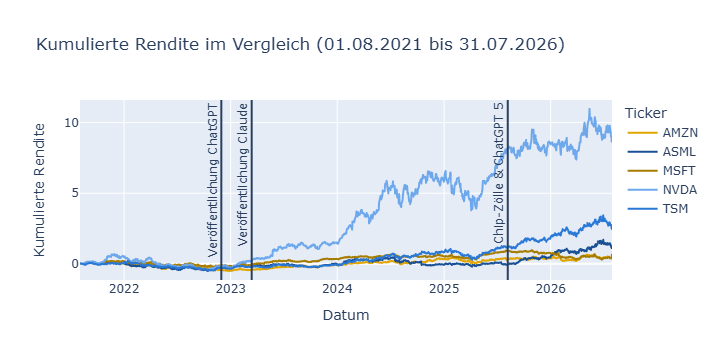

In [8]:
figur_kumulierte_rendite = plotly.express.line(
    kumulierte_rendite,
    color_discrete_map=farben,
    labels={"value": "Kumulierte Rendite", "Date": "Datum"},
    title="Kumulierte Rendite im Vergleich (01.08.2021 bis 31.07.2026)"
)

figur_kumulierte_rendite.add_vline(
    x=pandas.Timestamp("2022-11-30"),
    annotation_text="Veröffentlichung ChatGPT",
    annotation_position="top left",
    annotation_textangle=270
)

figur_kumulierte_rendite.add_vline(
    x=pandas.Timestamp("2023-03-14"),
    annotation_text="Veröffentlichung Claude",
    annotation_position="top left",
    annotation_textangle=270
)

figur_kumulierte_rendite.add_vline(
    x=pandas.Timestamp("2025-08-07"),
    annotation_text="Chip-Zölle & ChatGPT 5",
    annotation_position="top left",
    annotation_textangle=270
)

figur_kumulierte_rendite.show()

### Bedeutung der Zahlen

- Ein Wert von 10 bei NVIDIA (Ergebnis von `Kumulierte Rendite = (Endkapital / Startkapital) - 1`) bedeutet eine kumulierte Rendite von 1000 %
- Aufgelöst nach dem Endkapital: `Endkapital = Startkapital x (1 + Kumulierte Rendite)`
- Aus 1 EUR wären also 11 EUR geworden (`1 EUR x (1 + 10) = 11 EUR`)

### Schlussfolgerung

- Am Ende des Betrachtungszeitraums liegen alle drei Hardware-Unternehmen (blau) deutlich vor beiden Software-Unternehmen (gelb)
- Das stützt die eingangs formulierte Annahme, dass sich die Hardware-Ebene der KI-Wertschöpfungskette bislang stärker ausgezahlt als die Software-Ebene
- Offen bleibt, ob dieses höhere Wachstum auch mit einem höheren Risiko einhergeht, das untersucht die nächste Kennzahl Volatilität

## 3.2 Volatilität

- **Definition**:
    - Maß für die Schwankungsbreite der täglichen Rendite einer Aktie um ihren Mittelwert
    - Hohe Volatilität bedeutet große Kursschwankungen und damit höheres Risiko (TODO: Quelle)
- **Formel**: `Volatilität = Standardabweichung der täglichen Rendite * Wurzel(252)`
- **Umsetzung in Python**:
    - `taegliche_rendite.std()` berechnet die Standardabweichung je Unternehmen (pandas  n. d.)
    - `** 0.5` berechnet die Quadratwurzel von 252 (Anzahl der Handelstage pro Jahr) zur Annualisierung
    - Da sich die Schwankung unabhängiger täglicher Renditen über die Zeit aufsummiert, wächst die Standardabweichung mit der Wurzel der Zeit

In [9]:
volatilitaet = taegliche_rendite.std() * (252 ** 0.5)
volatilitaet

Ticker
AMZN    0.356498
ASML    0.432816
MSFT    0.279891
NVDA    0.518987
TSM     0.383796
dtype: float64

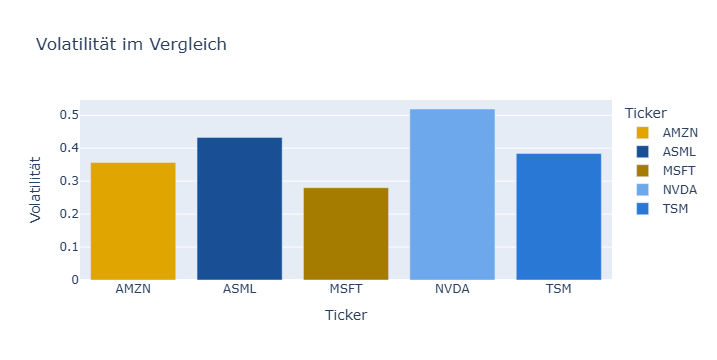

In [10]:
figur_volatilitaet = plotly.express.bar(
    volatilitaet,
    color=volatilitaet.index,
    color_discrete_map=farben,
    labels={"value": "Volatilität", "color": "Ticker"},
    title="Volatilität im Vergleich"
)

figur_volatilitaet.show()

### Bedeutung der Zahlen

- Bei 100 EUR Einsatz bedeutet eine Volatilität von ca. 0,52 (NVIDIA), dass der Wert im Jahresverlauf um ca. 52 EUR nach oben oder unten schwankt
- Eine Volatilität von ca. 0,28 (Microsoft) bedeutet eine Schwankung von ca. 28 EUR

### Schlussfolgerung

- Die Hardware-Ebene zeigte in 3.1 nicht nur eine höhere kumulierte Rendite, sondern hier auch eine höhere Volatität
- Höhere Renditechancen gehen mit größeren Kursschwankungen einher
- Offen bleibt, ob ob sich dieses höhere Risiko im Verhältnis zur erzielten Rendite tatsächlich gelohnt hat, das misst die nächste Kennzahl Sharpe Ratio

## 3.3 Sharpe Ratio

- **Definition**: Kennzahl, die Rendite und Risiko in einer einzigen Zahl zusammenführen
- **Formel**: `Sharpe Ratio = (Rendite - risikofreier Zinssatz) / Volatilität`
- **Vereinfachung**: Der risikofreie Zinssatz wird hier mit 0 angenommen, um die Berechnung einfach zu halten
- **Umsetzung in Python**
    - `kumulierte_rendite.iloc[-1]` (integer location) liefert den letzten Wert je Unternehmen, also die Gesamtrendite über den gesamten Zeitraum aus 3.1 (pandas, n. d.)
    - Division durch `volatilitaet` aus 3.2 ergibt die Sharpe Ratio je Unternehmen

In [11]:
sharpe_ratio = kumulierte_rendite.iloc[-1] / volatilitaet
sharpe_ratio

Ticker
AMZN     1.160696
ASML     2.885691
MSFT     2.323479
NVDA    17.167300
TSM      7.149655
dtype: float64

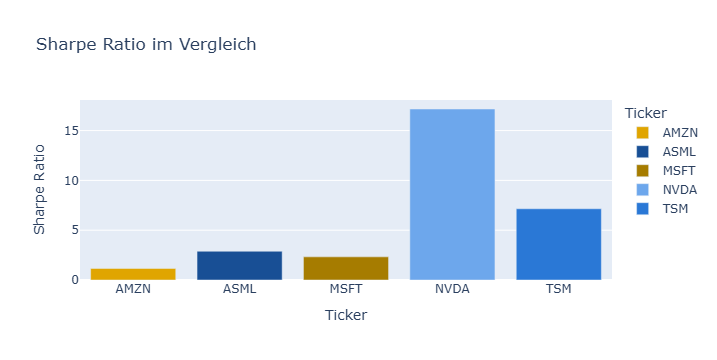

In [12]:
figure_sharpe_ratio = plotly.express.bar(
    sharpe_ratio,
    color=sharpe_ratio.index,
    color_discrete_map=farben,
    labels={"value": "Sharpe Ratio", "color": "Ticker"},
    title="Sharpe Ratio im Vergleich"
)
figure_sharpe_ratio.show()

### Bedeutung der Zahlen

- Ein Wert von 17,17 bei NVIDIA bedeutet, dass die erzielte Rendite ca. 17x so hoch wie das eingegangene Risiko (Volatilität) war
- Zum Vergleich Amazon: Die Rendite war nur 1,16x so hoch wie das Risiko
- Als grobe Orientierung gilt
    - Werte über 1 gelten als akzeptabel
    - über 2 als stark
    - über 3 als hervorragend (TODO: Quelle)

### Schlussfolgerung

- Auch hier bleibt der Hardware-Ebene vorne
- Das bestätigt den Eindruck aus 3.1 und 3.2: Die höhere Rendite der Hardware-Ebene war nicht nur ein Ergebnis von mehr eingegangenem Risiko, sondern hat sich auch im Verhältnis zum Risiko ausgezahlt
- Damit zeigt sich: In diesem Betrachtungszeitraum hätte sich ein Investment in die Hardware-Ebene sowohl absolut als auch risikoadjustiert stärker gelohnt als ein Investment in die Software-Ebene

## 3.4 Maximaler Drawdown

- **Definition**: Der maximale Drawdown zeigt den größten Kursrückgang, den eine Aktie im Betrachtungszeitraum erlebt hat (TODO: Quelle)
- **Formel**: `Maximaler Drawdown = (Kurs - bisheriges Hoch) / bisheriges Hoch`
- **Umsetzung in Python**:
    - Um den maximalen Drawdown zu berechnen, wird zunächst für jeden Tag der bisher höchste erreichte Kurs benötigt. Dafür bietet pandas die Methode `cummax()` (cumulative maximum) an (pandas, n. d.).
    - `cclose.cummax()` gibt für jeden Tag nicht den aktuellen Kurs zurück, sondern den höchsten Schlusskurs, der bis zu diesem Tag jemals erreicht wurde

In [13]:
bisheriges_hoch = close.cummax()
taeglicher_drawdown = (close - bisheriges_hoch) / bisheriges_hoch
maximaler_drawdown = taeglicher_drawdown.min()
maximaler_drawdown

Ticker
AMZN   -0.557258
ASML   -0.568618
MSFT   -0.371485
NVDA   -0.663351
TSM    -0.564666
dtype: float64

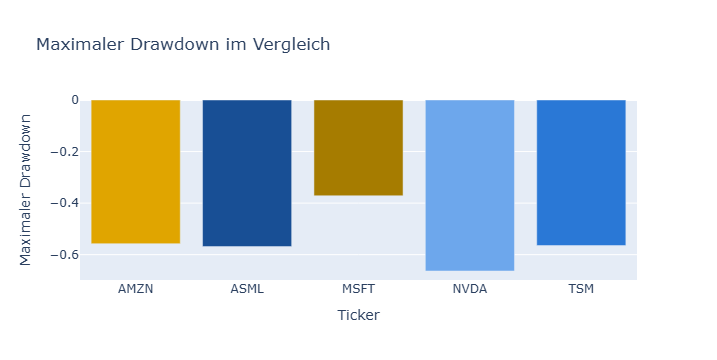

In [14]:
figure_maximaler_drawdown = plotly.express.bar(
    maximaler_drawdown,
    color=maximaler_drawdown.index,
    color_discrete_map=farben,
    labels={"value": "Maximaler Drawdown"},
    title="Maximaler Drawdown im Vergleich"
)
figure_maximaler_drawdown.update_layout(showlegend=False)
figure_maximaler_drawdown.show()

### Bedeutung der Zahlen

- Ein Wert von -0,66 bei NVIDIA bedeutet, dass der Kurs im Betrachtungszeitraum zwischenzeitlich um 66 % von seinem bisherigen Höchststand gefallen ist
- Bei einem Investment von 100 EUR zum Zeitpunkt des damaligen Hochs wäre der Wert zwischenzeitlich auf etwa 34 EUR gesunken

**Auffällig ist:**
- NVIDIA hat sowohl die höchste kumulierte Rendite (3.1), die höchste Volatilität (3.2) und den größten maximalen Drawdown
- Microsoft dagegen hat sowohl die niedrigste Volatilität als auch den kleinstne maximalen Drawdown
- Das bestätigt einen wiederkehrenden Zusammenhang: Höhere Rendite geht mit höherem Risiko einher

### Schlussfolgerung

Der maximale Drawdown bestätigt das Bild aus 3.2 (Volatilität) und 3.3 (Sharpe Ratio):
- Die drei Hardware Unternehmen haben durchgehend höhere maximale Verluste erlitten (-56 % bis -66 %)
- Die beiden Software Unternehmen haben niedrigere maximale Verluste erlitten (-37 % bis -55 %)
    -  Amazon liegt mit -55 % zwar noch unter den Hardware Unternehmen, aber der Abstand ist verschwindend gering
 
Für die Leitfrage bedeutet das:
- Wer im Betrachtungszeitraum in Hardware-Unternehmen investiert hat, wurde mit höheren Rendite belohnt, musste aber auch die größten zwischenzeitlichen Verluste ertragen
- Die höhere Rendite ist also nicht "kostenlos", sondern geht mit einem entsprechenden Risiko einher
    - Ein Muster, das sich über alle bisherigen Kennzahlen (Volatilität, Sharpe Ratio, Maximaler Drawdown) bestätigt

## 3.5 Korrelation / Diversifikation

- **Definition**: Die Korrelation zeigt, ob sich zwei Aktien ähnlich oder unterschiedlich bewegen. Der Wert liegt immer zwischen -1 und +1.
    - Nahe +1 heißt, beide Aktien bewegen sich fast gleich
    - Nahe -1 heißt, beide Aktien bewegen sich gegenläufig
    - Nahe 0 heißt, es gibt keinen Zusammenhang (TODO: Quelle)
- **Formel**: `Korrelation(A, B) = Kovarianz(A, B) / (Volatilität A x Volatilität B)`
    - Kovarianz zeigt, ob zwei Aktien sich eher in die gleiche Richtung bewegen (positiv) oder in unterschiedliche Richtungen (negativ)
    - Durch das Teilen durch die Volatilität beider Aktien wird der Wert auf den Bereich zwischen -1 und +1 normiert
- **Umnsetzung in Python**: pandas berechnet die Korrelation nicht manuell über Kovarianz und Volatilität, sondern direkt mit der Methode `corr()`
    - `corr()` berechnet automatisch die Korrelation zwischen jeder möglichen Kombination von zwei Unternehmen und gibt das Ergebnis als Tabelle (Korrelationsmatrix) zurück

In [15]:
korrelation = taegliche_rendite.corr()
korrelation

Ticker,AMZN,ASML,MSFT,NVDA,TSM
Ticker,,,,,
AMZN,1.000000,0.510024,0.612100,0.538559,0.453532
ASML,0.510024,1.000000,0.454840,0.659558,0.705694
MSFT,0.612100,0.454840,1.000000,0.570029,0.428812
NVDA,0.538559,0.659558,0.570029,1.000000,0.681444
TSM,0.453532,0.705694,0.428812,0.681444,1.000000


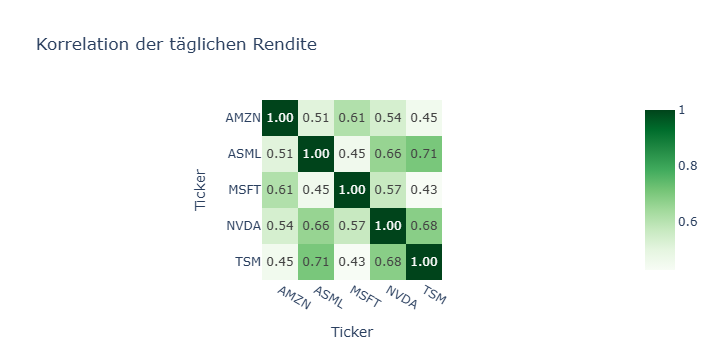

In [25]:
figure_korrelation = plotly.express.imshow(
    korrelation,
    color_continuous_scale="Greens",
    text_auto=".2f",
    title="Korrelation der täglichen Rendite"
)
figure_korrelation.show()

### Bedeutung der Zahlen

- Die drei Hardware-Firmen korrelieren untereinander besonders stark, durchschnittlich 0,68:
    - ASML+NVDA: 0.66
    - ASML+TSM: 0.71
    - NVDA+TSM: 0.68
- Die beiden Software-Firmen korrelieren auch miteinander:
    - AMZN+MSFT: 0.61
- Die Hardware- und Software-Firmen korrelieren am wenigsten miteinander, durchschnittlich 0,49:
    - ASML+AMZN: 0.51
    - ASML+MSFT: 0.45
    - NVDA+AMZN: 0.54
    - NVDA+MSFT: 0.57
    - TSM+AMZN: 0.45
    - TSM+MSFT: 0.43
- Der höchste Wert liegt bei ASML und TSM mit 0,71 (beides Hardware)
- Der niedrigste Wert liegt bei Microsoft und TSM mit 0,43 (Software und Hardware)

### Schlussfolgerung

Die Korrelationsanalyse liefert die bisher deutlichste Antwort auf die Leitfrage
- Aktien derselben Ebene bewegen sich stärker gemeinsam als Aktien unterschiedlicher Ebenen
- Besonders die drei Hardware-Unternehmen sind eng miteinander verbunden
    - Das passt zur Annahme aus Kapitel 1, dass sie über eine gemeinsame Lieferkette wirtschaftlich voneinander abhängen
- Zwischen Hardware- und Softwareunternehmen ist der Zusammenhang auch positiv, aber merklich schwächer
    - Beide Ebenen profitieren vom gleichen KI-Trend, unterliegen aber nicht denselben Marktkräften

# 4. Gesamtbild und Vergleich

# 5. Fazit und Reflexion

# Abbildungsverzeichnis

# Quellenverzeichnis